In [ ]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import equilibrium_critical_correlations as eq
from common_imports import *

r_max = 100
n_values = [1,2,3,4]
folder = "data/"
tau_filenames = [folder+f"data_Pn_corr_n{n}_rmax{r_max}.npz" for n in n_values]
critical_corr_filenames = [folder+f"critical_correlation_n{n}_rmax{r_max}.npz.npy" for n in n_values]
r= np.load(tau_filenames[0])["r"]
taus = np.load(folder+"data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz")['taus']
states= np.load(folder+"data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz")['states']
states2=np.load(folder+"data_KZ_L500_t_tau_N100_tau1.0e-03-3.2e+03.npz")['states']
PP_quenched = ([np.load(filename)['PP_corr'] for filename in tau_filenames])
crit = ([np.load(filename) for filename in critical_corr_filenames])

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:48<00:00,  2.08it/s]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31100/1993031160.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


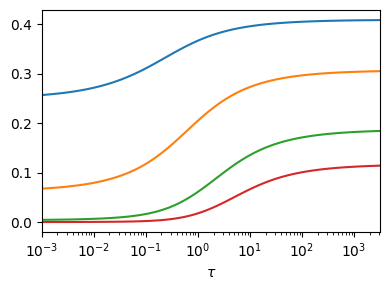

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
colors = [f"C{i}" for i in range(len(n_values))]
n_values=[2,4,8,12]
for i, n in enumerate(n_values):
    P1 = np.array([kz.P_n(n, s) for s in tqdm(states)], dtype=complex).real
    #P2 = np.array([kz.P_n(n, s) for s in states2], dtype=complex).real

    #ar1 = P1 * (1 - P1)
   # var2 = P2 * (1 - P2)

    plt.plot(taus, P1, color=colors[i])
   # plt.plot(taus, P2, "--", color=colors[i], label=fr"$n={n}$")
xlim(taus[0],taus[-1])
plt.xscale("log")
#ylim(0,.26)
#plt.yscale("log")
plt.xlabel(r"$\tau$")
#plt.ylabel(r"$\langle P_n\rangle(1-\langle P_n\rangle)$")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("Felllowship_figure_5.png")
plt.show()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31100/1365188500.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  P1 = np.array([kz.P_n(n, s) for s in states], dtype=float)


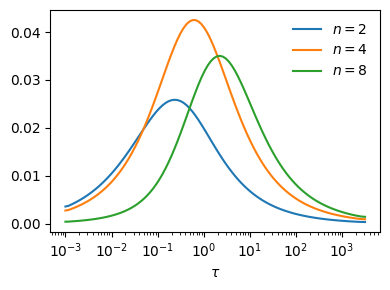

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
colors = [f"C{i}" for i in range(len(n_values))]

for i, n in enumerate(n_values):
    P1 = np.array([kz.P_n(n, s) for s in states], dtype=float)
    var1 = P1 

    # numerical derivative wrt log(τ) for smoother scaling plots
    dvar1 = np.gradient(var1, np.log(taus))

    plt.plot(taus, dvar1, color=colors[i], label=fr"$n={n}$")

plt.xscale("log")
plt.xlabel(r"$\tau$")
#plt.ylabel(r"$\partial_\tau[\langle P_n\rangle(1-\langle P_n\rangle)]$")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("Fellowship_figure_5_derivative.png", dpi=300)
plt.show()
